In [29]:
#Central Limit Theorem: Example with LIG Conductivity Measurements
#Assume that a large number of independent conductivity measurements of laser-induced graphene (LIG) are available,
#all obtained under identical fabrication conditions (same laser power, scan speed, atmosphere, etc.). Individual measurements 
#fluctuate due to experimental noise, local inhomogeneities, and contact resistance variations. Importantly, the distribution of these raw
#measurements is not assumed to be Gaussian.
#We now investigate the distribution of sample means obtained by repeatedly averaging a fixed number of conductivity measurements.

In [1]:
#Preparation
import numpy as np
import matplotlib.pyplot as plt


In [5]:
#We also define a Gaussian distribution function:
def gaussian(x, loc, s):
    return (1 / np.sqrt(2 * np.pi * s**2) *
            np.exp(-(x - loc)**2 / (2 * s**2)))


In [6]:
#Population: Realistic LIG Conductivity Data
#Suppose the conductivity of LIG (in S/cm) follows a right-skewed distribution, which is commonly observed in percolative or defect-limited transport.
#We model this using a log-normal distribution with a mean conductivity around 180 S/cm.

rng = np.random.default_rng(42)

# "Raw" conductivity measurements (non-Gaussian)

population = rng.lognormal(mean=np.log(180), sigma=0.25, size=200_000)


In [7]:
#Sampling and Computing Sample Means. We now repeatedly draw samples of fixed size and compute their means.

sample_size = 50      # number of measurements per experiment
n_means = 500         # number of independent experiments

means = []

for i in range(n_means):
    sample = rng.choice(population, size=sample_size, replace=False)
    means.append(sample.mean())

means = np.array(means)


Text(0, 0.5, 'Probability density')

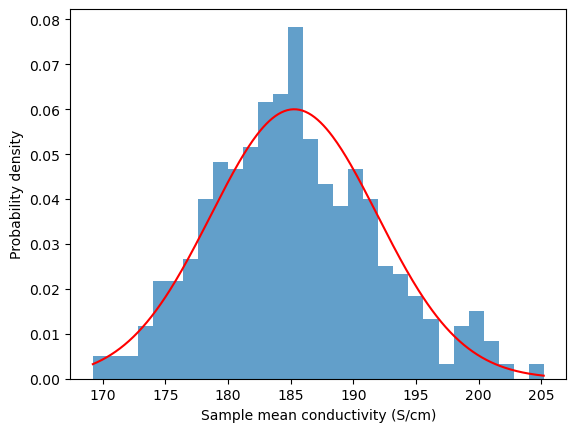

In [8]:
#Visualization
plt.hist(means, bins=30, density=True, alpha=0.7)

x = np.linspace(means.min(), means.max(), 300)
plt.plot(x, gaussian(x, means.mean(), means.std()), 'r-')

plt.xlabel("Sample mean conductivity (S/cm)")
plt.ylabel("Probability density")


In [35]:
#Interpretation
#Although the original conductivity measurements are drawn from a non-Gaussian (log-normal) distribution, the distribution of the sample means closely 
#follows a Gaussian shape. This behavior is a direct consequence of the central limit theorem.
#The mean of the distribution of sample means approaches the true population mean, while its width (standard deviation) decreases
#with increasing sample size. Increasing sample_size would lead to an even narrower and more sharply peaked Gaussian distribution.
    

In [36]:
#Discussion
#This example illustrates a key practical implication of the central limit theorem for experimental science:
#Individual conductivity measurements may follow complex, non-Gaussian distributions.
#Averages of sufficiently large samples exhibit Gaussian statistics, regardless of the underlying distribution.
#As a result, Gaussian error propagation and confidence intervals are often justified when working with averaged experimental quantities.
#Importantly, the CLT does not state that a single sample mean is accurate (this is the role of the law of large numbers). Instead, it describes the distribution of many sample means, making it a powerful tool for uncertainty analysis and statistical inference